In [1]:
%load_ext autoreload
%autoreload 2
import os
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from data_handling import MassBalance
from get_ddf import get_ddf_df


import socket
if 'trace' in socket.gethostname():
    base_fp = '/trace/group/rounce/cvwilson/Output/ddf/'
    home_fp = '/trace/home/cvwilson/research/'
else:
    base_fp = 'C:/Users/cvw30/Research/Output/'
    home_fp = 'C:/Users/cvw30/Research/'

colors = ['#63c4c7','#fcc02e','#4D559C','#60C252','#BF1F6A',
              '#F77808','#298282','#999999','#FF89B0','#427801']

coord_dict = {'wolverine':'60.5_-148.7',
                'kahiltna':'63.0_-151.2',
                'kennicott':'61.5_-143.1',
                'taku':'58.5_-134.3',
                'lemoncreek':'58.5_-134.3',
                'gulkana':'63.5_-145.625'}

In [2]:
site = 'K17b'
glacier = 'kahiltna'
model_fn = base_fp + f'gulkana{site}_2026_02_12_base_kp1_0.nc'

# initialize data class
data = MassBalance(glacier,site, use='benchmark annual')

# open model dataset, get data and plot
ds = xr.open_dataset(model_fn)
data.get_model_mb(ds)
# data.plot_mb()

In [93]:
site_dict = {
    'kahiltna':['K17b','K53'], # KAHILTNA     'KPS', 'K14C',
    'kennicott':['GTH','GTL'], # KENNICOTT
    # '01.00570':['AU','B','D'], # GULKANA
    'wolverine':['N','B','EC'], # WOLVERINE
    'lemon_creek':['B','C','D'], # LEMON CREEK
    'taku':['MG1','NWB1','TKG3'], # TAKU
}

date_dict = {'wolverine':'02_06',
                'kahiltna':'02_05',
                'kennicott':'02_09',
                'taku':'02_10',
                'lemon_creek':'', # DONT HAVE
                'gulkana':'02_03'}

best_dict = {}
for glacier in ['taku','lemon_creek']:
    best_dict[glacier] = {}
    for site in site_dict[glacier]:
        data = MassBalance(glacier, site, use='benchmark annual')
        min_mae = np.inf
        # options = ['qmwindkp0.5','qmwindkp1','qmwindkp2']
        options = ['qmlemonkp1','qmlemonkp2','qmlemonkp3','qmlemonwindkp3']
        # options = ['qmwind','qmall','kp0.5','kp1','long','qmallkp2']
        for option in options: # 
            # retrieve date for filename
            if option == 'qmwindkp0.5':
                date = '02_13' # date_dict[glacier]
                # glac = glacier
            elif 'lemonwind' in option:
                date = '02_16'
            elif 'lemon' in option:
                date = '02_15'
            else:
                date = '02_12'
                # glac = glacier # 'gulkana'

            
            model_fn = base_fp + f'{glacier}{site}_2026_{date}_base_{option}_0.nc'
            if os.path.exists(model_fn):
                ds = xr.open_dataset(model_fn)
                if ds.attrs == {}:
                    continue
            else:
                # print('Model run failed for', glacier, site, option)
                continue

            # open model dataset of interest and get seasonal mass balance
            data.get_model_mb(ds)

            # check if the MAE is smaller than running min
            mae = data.mae()
            if mae < min_mae:
                min_mae = mae
                best_dict[glacier][site] = [option, mae, ds]

for item in best_dict:
    print(item)
    for site in best_dict[item]:
        print('      ',site, best_dict[item][site][0], best_dict[item][site][1])

taku
       MG1 qmlemonkp2 1.236241920244637
       NWB1 qmlemonkp2 1.0471800735638213
       TKG3 qmlemonwindkp3 1.9146191263300822
lemon_creek
       B qmlemonwindkp3 1.2085866120390267
       C qmlemonwindkp3 2.0455381439908096
       D qmlemonkp3 1.8470637471809965


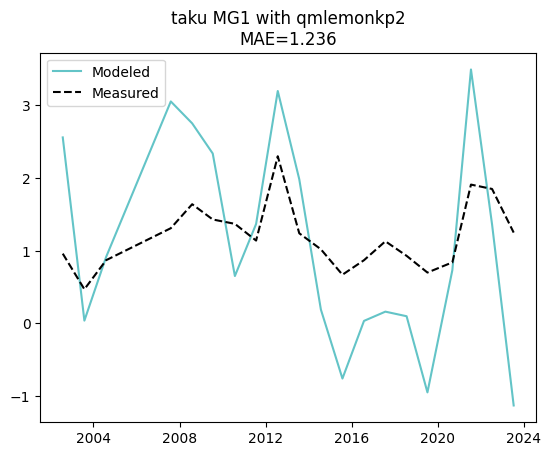

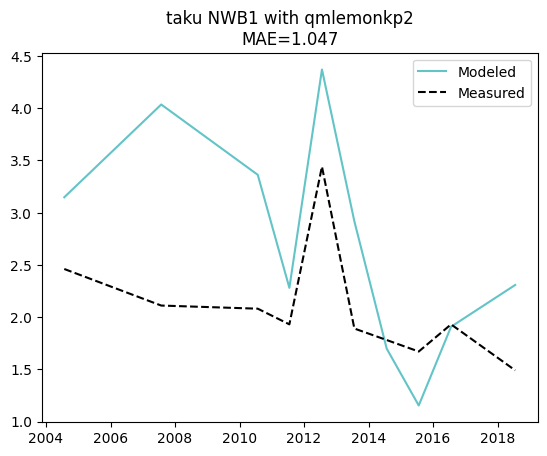

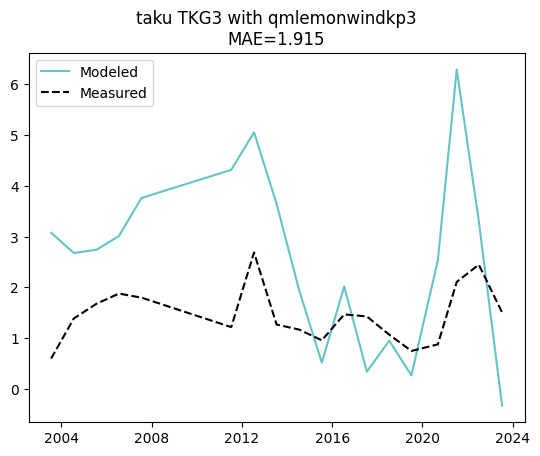

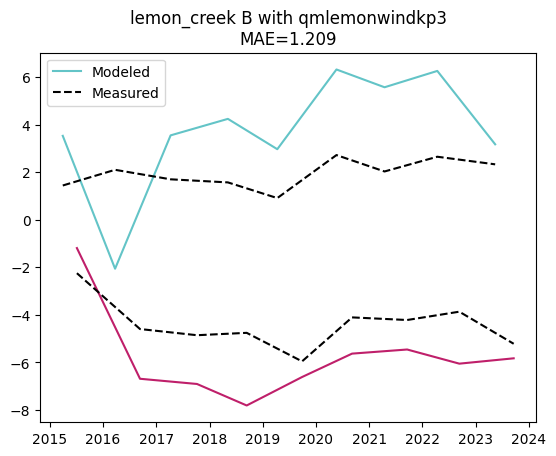

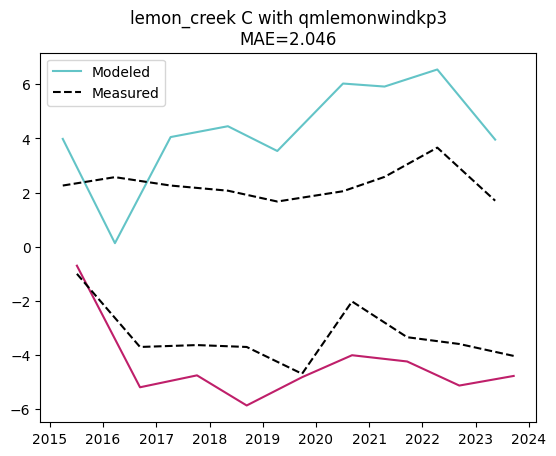

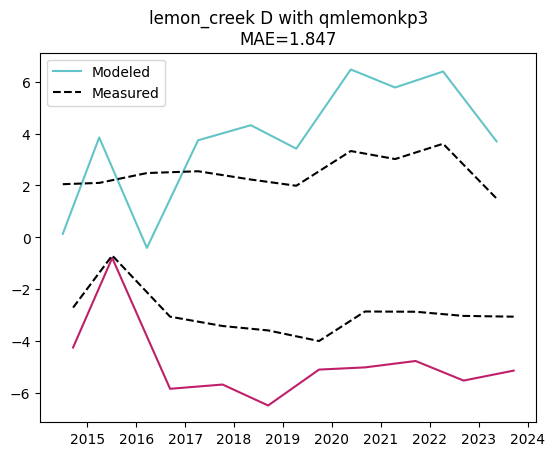

In [90]:
for glacier in best_dict:
    for site in best_dict[glacier]:
        option = best_dict[glacier][site][0]
        MAE = best_dict[glacier][site][1]
        if True: # MAE > 0.7:
            # reinitialize data class
            data = MassBalance(glacier, site, use='benchmark')
            data.get_model_mb(best_dict[glacier][site][2])
            fig, ax = data.plot_mb()
            ax.set_title(f'{glacier} {site} with {option}\nMAE={MAE:.3f}')
            plt.show()

In [ ]:
acceptable = {
    'gulkana':{'AU':'gulkanaAU_2026_02_03_base_long_0.nc',
               'B':'gulkanaB_2026_02_03_base_long_0.nc',
               'D':'gulkanaD_2026_02_03_base_long_0.nc',
               },
    'wolverine':{'N':'wolverineN_2026_02_12_base_qmwindkp1_0.nc',
                 'EC':'wolverineEC_2026_02_12_base_qmwindkp1_0.nc',
                 },
    'kahiltna':{'K17b':'kahiltnaK17b_2026_02_13_base_qmwindkp0.5_0.nc',
                 'K53':'kahiltnaK53_2026_02_12_base_qmwindkp2_0.nc',
                 },
    'kennicott':{'GTH':'kennicottGTH_2026_02_12_base_qmwindkp1_0.nc',
                 'GTL':'kennicottGTL_2026_02_13_base_qmwindkp0.5_0.nc',
                 },
    'taku':{'MG1':'takuMG1_2026_02_12_base_qmwindkp1_0.nc',
            'NWB1':'takuNWB1_2026_02_12_base_qmwindkp1_0.nc',
            }
}
for glacier in acceptable:
    coords = coord_dict[glacier]
    ds_bcd = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/BCDP002_{coords}.nc')
    ds_bcw = xr.open_dataset(f'../../climate_data/MERRA2/{coords}/BCWT002_{coords}.nc')
    ds_bc = ds_bcd['BCDP002'] + ds_bcw['BCWT002']
    
    for site in acceptable[glacier]:
        ds = xr.open_dataset(base_fp + acceptable[glacier][site])
        out = base_fp+f'{glacier}{site}_df.csv'
        df = get_ddf_df(ds, ds_bc, plot_corr=True, n_rolling_bc=5, output_fn=out)

        # annual_MB = ds.MB.resample(time='YS-OCT').sum().mean()
        # if annual_MB > 0:
        #     print(glacier, site, 'is accumulation area')
        # else:
        #     print(glacier, site, 'is ablation area')

gulkana AU is ablation area
gulkana B is ablation area
gulkana D is accumulation area
wolverine N is ablation area
wolverine EC is accumulation area
kahiltna K17b is accumulation area
kahiltna K53 is ablation area
kennicott GTH is accumulation area
kennicott GTL is ablation area
taku MG1 is accumulation area
taku NWB1 is accumulation area


/tmp/ipykernel_628031/33411357.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


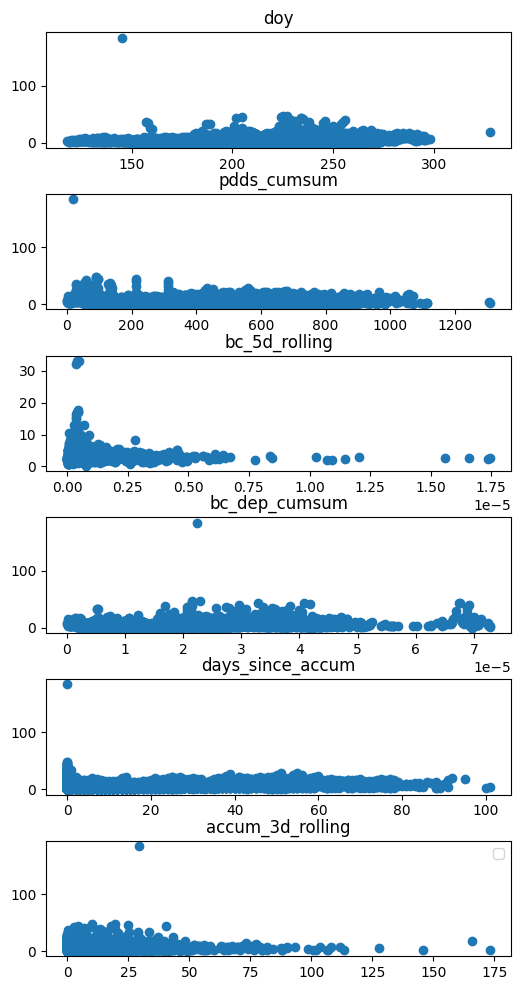

In [81]:
vars = ['doy','pdds_cumsum','bc_5d_rolling', 'bc_dep_cumsum','days_since_accum', 'accum_3d_rolling']
fig, axes = plt.subplots(len(vars), figsize=(6, 2*len(vars)), gridspec_kw={'hspace':0.4})

df_all = None 
for glacier in ['taku','wolverine','gulkana','kahiltna','kennicott']:
    for site in site_dict[glacier]:
        df = pd.read_csv(base_fp+f'{glacier}{site}_df.csv', parse_dates=True, index_col=0)
        if df_all is None:
            df_all = df 
        else:
            df_all = pd.concat([df_all, df])

df_all['doy'] = pd.to_datetime(df_all.index).day_of_year
for ax, var in zip(axes, vars):
    ax.scatter(df_all[var], df_all['ddf'])
    ax.set_title(var)

ax.legend()
plt.show()